# Sección 7 (parte B): F1 de test contra fracción de datos de AG News

In [1]:
import json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import evaluation as EV
import clasificacion as C

np.seterr(all="ignore")
CACHE = Path("cache"); RESULTS = Path("results"); FIGS = RESULTS / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
CSV = RESULTS / "curva_datos.csv"
pd.options.display.float_format = "{:.4f}".format

SGNS_RUNS = {"SGNS (d300)": "d300_c100", "SGNS (d100)": "d100_c100"}     # nombre mostrado -> run de A (<run>_W_in.npy)
GENSIM_LEGACY = "gensim (d100, 10 ep)"   # corrida anterior (d100, 10 epochs): sus filas ya calculadas se conservan, no se reentrena
FRACS = [0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 1.00]
SEEDS = [0, 1, 2, 3, 4]
EMB_LRS = [1e-3, 1e-2]


def max_epochs(frac):                 # con pocos datos hay pocos pasos por epoch: se permiten más epochs
    return 200 if frac <= 0.05 else 100 if frac <= 0.25 else 40

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
D = C.load_agnews(val_frac=0.1, seed=42)             # mismo split que la sección 6
gensim_space = EV.load_kv(CACHE / "gensim_d300_e3.kv", name="gensim (d300, 3 ep)")
glove_space = EV.EmbeddingSpace.from_keyed_vectors(api.load("glove-wiki-gigaword-100"), name="GloVe-100")
sgns_spaces = [EV.load_sgns(CACHE, r, name=n) for n, r in SGNS_RUNS.items()]

inits = {"Aleatorio": dict(w2i=C.build_vocab(D["train_tok"], min_count=2), E=None)}
for s in [*sgns_spaces, gensim_space, glove_space]:
    if s is not None:
        E, w2i = C.embedding_table(s)
        inits[s.name] = dict(w2i=w2i, E=E)
for n, cfg in inits.items():
    cfg["dim"] = 100 if cfg["E"] is None else cfg["E"].shape[1]       # la dimensión la fija la matriz de embeddings
    cfg["vocab_size"] = len(cfg["w2i"]) + 1
    cfg["train_full"], cfg["val"], cfg["test"] = (C.Encoded(D[f"{k}_tok"], D[f"{k}_y"], cfg["w2i"]) for k in ("train", "val", "test"))

variantes = []
for n in inits:
    variantes += [(n, "entrenada", False)] if n == "Aleatorio" else [(n, "congelada", True), (n, "fine-tuning", False)]
print("Inicializaciones:", list(inits), "| variantes:", len(variantes) + 1, "(con TF-IDF)")

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Inicializaciones: ['Aleatorio', 'SGNS (d300)', 'SGNS (d100)', 'gensim (d300, 3 ep)', 'GloVe-100'] | variantes: 10 (con TF-IDF)


## Experimento

In [3]:
def fila(modelo, variante, frac, seed, n_train, val_f1, test, **extra):
    return dict(modelo=modelo, variante=variante, frac=frac, seed=seed, n_train=n_train, val_f1=val_f1,
                test_f1=test["f1"], test_acc=test["acc"], **extra)


def uni_bi(toks):
    return toks + [a + " " + b for a, b in zip(toks, toks[1:])]


def correr_tfidf(frac, seed):
    idx = C.stratified_fraction(D["train_y"], frac, seed=seed)
    toks, y = [D["train_tok"][i] for i in idx], D["train_y"][idx]
    vec = TfidfVectorizer(analyzer=uni_bi, min_df=2, sublinear_tf=True)
    X, Xv, Xt = vec.fit_transform(toks), vec.transform(D["val_tok"]), vec.transform(D["test_tok"])
    best = None
    for Cv in [3, 10, 30]:
        clf = LogisticRegression(C=Cv, max_iter=2000).fit(X, y)
        f1 = C.metrics(D["val_y"], clf.predict(Xv))["f1"]
        if best is None or f1 > best[0]:
            best = (f1, Cv, clf)
    f1, Cv, clf = best
    return fila("TF-IDF + LogReg", "C elegido", frac, seed, len(idx), f1, C.metrics(D["test_y"], clf.predict(Xt)), emb_lr=np.nan, C=Cv)


def correr_neuronal(init, modo, freeze, frac, seed):
    cfg = inits[init]
    idx = C.stratified_fraction(D["train_y"], frac, seed=seed)
    tr = cfg["train_full"].subset(idx)
    cand = []
    for elr in ([None] if freeze else EMB_LRS):
        model, info = C.train_classifier(tr, cfg["val"], cfg["vocab_size"], cfg["dim"], pretrained=cfg["E"], freeze=freeze,
                                         epochs=max_epochs(frac), patience=5, emb_lr=elr, seed=1000 + seed, verbose=False)
        cand.append((info["val"]["f1"], elr, model, info))
    f1, elr, model, info = max(cand, key=lambda c: c[0])
    return fila(init, modo, frac, seed, len(idx), f1, C.evaluate_test(model, cfg["test"]),     # test: una vez, modelo ya elegido
                emb_lr=elr if elr else np.nan, best_epoch=info["best_epoch"])


res = pd.read_csv(CSV) if CSV.exists() else pd.DataFrame()
if len(res):
    res["modelo"] = res["modelo"].replace({"gensim": GENSIM_LEGACY})      # filas de la corrida anterior: se conservan con su configuración en la etiqueta
hechos = set(zip(res.modelo, res.variante, res.frac, res.seed)) if len(res) else set()
t0 = time.time()
for frac in FRACS:
    for seed in SEEDS:
        nuevas = []
        if frac < 1.0 or seed == 0:                       # con el 100 % TF-IDF es determinista: una sola corrida
            if ("TF-IDF + LogReg", "C elegido", frac, seed) not in hechos:
                nuevas.append(correr_tfidf(frac, seed))
        for init, modo, freeze in variantes:
            if (init, modo, frac, seed) not in hechos:
                nuevas.append(correr_neuronal(init, modo, freeze, frac, seed))
        if nuevas:
            res = pd.concat([res, pd.DataFrame(nuevas)], ignore_index=True)
            res.to_csv(CSV, index=False)
    print(f"fracción {frac:>5.0%} lista  ({time.time() - t0:.0f}s acumulados)")
res = pd.read_csv(CSV)
print(len(res), "corridas en", CSV)

fracción    1% lista  (0s acumulados)
fracción    2% lista  (0s acumulados)
fracción    5% lista  (0s acumulados)
fracción   10% lista  (0s acumulados)
fracción   25% lista  (0s acumulados)
fracción   50% lista  (0s acumulados)
fracción  100% lista  (0s acumulados)
416 corridas en results/curva_datos.csv


## Resultados

In [4]:
res["curva"] = np.where(res.variante.isin(["entrenada", "C elegido"]), res.modelo, res.modelo + " · " + res.variante)
agg = res.groupby(["curva", "frac"]).test_f1.agg(["mean", "std", "count"]).reset_index()
orden = list(dict.fromkeys(res.curva))
tabla = agg.pivot(index="curva", columns="frac", values="mean").loc[orden]
tabla_std = agg.pivot(index="curva", columns="frac", values="std").loc[orden]
tabla.columns = [f"{c:.0%}" for c in tabla.columns]; tabla_std.columns = tabla.columns
print("F1 macro de test, media sobre semillas (el 100 % de TF-IDF es una sola corrida):")
display(tabla)
print("Desviación estándar entre semillas:")
display(tabla_std)

F1 macro de test, media sobre semillas (el 100 % de TF-IDF es una sola corrida):


,1%,2%,5%,10%,25%,50%,100%
curva,,,,,,,
TF-IDF + LogReg,0.8216,0.8509,0.8746,0.8899,0.9050,0.9147,0.9233
Aleatorio,0.8104,0.8353,0.8590,0.8781,0.8956,0.9069,0.9163
"gensim (d100, 10 ep) · congelada",0.8559,0.8629,0.8717,0.8778,0.8862,0.8916,0.8954
"gensim (d100, 10 ep) · fine-tuning",0.8632,0.8725,0.8850,0.8937,0.9005,0.9083,0.9146
GloVe-100 · congelada,0.8684,0.8741,0.8835,0.8860,0.8936,0.9008,0.9065
GloVe-100 · fine-tuning,0.8728,0.8793,0.8911,0.8989,0.9066,0.9132,0.9192
SGNS (d300) · congelada,0.8608,0.8687,0.8784,0.8843,0.8911,0.8987,0.9064
SGNS (d300) · fine-tuning,0.8644,0.8730,0.8868,0.8939,0.9024,0.9077,0.9147
"gensim (d300, 3 ep) · congelada",0.8556,0.8640,0.8723,0.8780,0.8862,0.8876,0.8934


Desviación estándar entre semillas:


,1%,2%,5%,10%,25%,50%,100%
curva,,,,,,,
TF-IDF + LogReg,0.0054,0.0040,0.0023,0.0027,0.0026,0.0018,NaN
Aleatorio,0.0025,0.0077,0.0042,0.0027,0.0018,0.0032,0.0021
"gensim (d100, 10 ep) · congelada",0.0055,0.0027,0.0028,0.0039,0.0024,0.0024,0.0030
"gensim (d100, 10 ep) · fine-tuning",0.0037,0.0033,0.0026,0.0024,0.0016,0.0028,0.0009
GloVe-100 · congelada,0.0024,0.0019,0.0007,0.0020,0.0022,0.0023,0.0006
GloVe-100 · fine-tuning,0.0036,0.0032,0.0021,0.0018,0.0027,0.0019,0.0005
SGNS (d300) · congelada,0.0024,0.0028,0.0013,0.0008,0.0024,0.0013,0.0017
SGNS (d300) · fine-tuning,0.0033,0.0032,0.0023,0.0012,0.0013,0.0019,0.0023
"gensim (d300, 3 ep) · congelada",0.0027,0.0030,0.0019,0.0012,0.0019,0.0019,0.0026


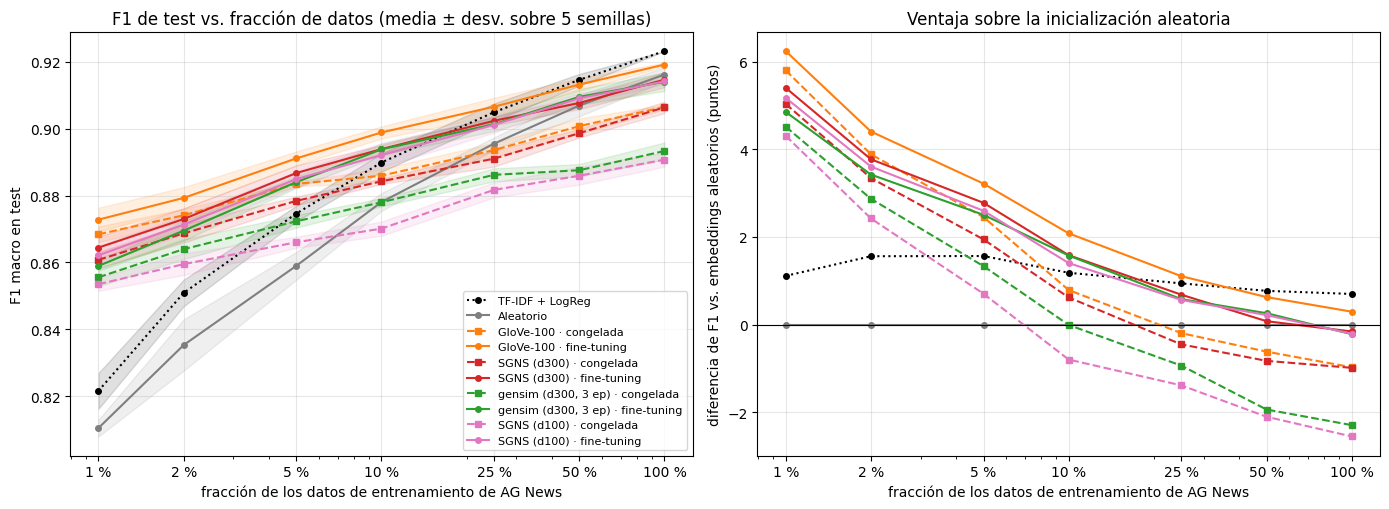

In [5]:
colores = {"Aleatorio": "tab:gray", "SGNS (d300)": "tab:red", "SGNS (d100)": "tab:pink", "gensim (d300, 3 ep)": "tab:green", "GloVe-100": "tab:orange", "TF-IDF + LogReg": "black"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
base = agg[agg.curva == "Aleatorio"].set_index("frac")["mean"]
for curva in [c for c in orden if c.split(" · ")[0] in colores]:          # la corrida anterior de gensim (d100) queda en la tabla, no en la figura
    d = agg[agg.curva == curva].sort_values("frac")
    modelo = curva.split(" · ")[0]
    estilo = "--" if curva.endswith("congelada") else ":" if modelo == "TF-IDF + LogReg" else "-"
    mk = "s" if curva.endswith("congelada") else "o"
    axes[0].plot(d.frac * 100, d["mean"], estilo, marker=mk, ms=4, color=colores[modelo], label=curva)
    axes[0].fill_between(d.frac * 100, d["mean"] - d["std"].fillna(0), d["mean"] + d["std"].fillna(0), color=colores[modelo], alpha=0.12)
    axes[1].plot(d.frac * 100, 100 * (d.set_index("frac")["mean"] - base), estilo, marker=mk, ms=4, color=colores[modelo], label=curva)
for ax in axes:
    ax.set_xscale("log"); ax.set_xticks([1, 2, 5, 10, 25, 50, 100]); ax.set_xticklabels(["1 %", "2 %", "5 %", "10 %", "25 %", "50 %", "100 %"])
    ax.set_xlabel("fracción de los datos de entrenamiento de AG News"); ax.grid(alpha=0.3)
axes[0].set_ylabel("F1 macro en test"); axes[0].set_title("F1 de test vs. fracción de datos (media ± desv. sobre 5 semillas)")
axes[1].set_ylabel("diferencia de F1 vs. embeddings aleatorios (puntos)"); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Ventaja sobre la inicialización aleatoria")
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(FIGS / "f1_vs_fraccion_datos.png", dpi=140); plt.show()

In [6]:
# Variante ganadora de cada inicialización a 1 % y a 100 % (por F1 de test medio) y diferencia con TF-IDF
rows = []
for f in [0.01, 0.10, 1.00]:
    d = agg[agg.frac == f].set_index("curva")["mean"].sort_values(ascending=False)
    rows.append(pd.DataFrame({"curva": d.index, f"{f:.0%}": d.values}).set_index("curva"))
pd.concat(rows, axis=1)

,1%,10%,100%
curva,,,
GloVe-100 · fine-tuning,0.8728,0.8989,0.9192
GloVe-100 · congelada,0.8684,0.8860,0.9065
SGNS (d300) · fine-tuning,0.8644,0.8939,0.9147
"gensim (d100, 10 ep) · fine-tuning",0.8632,0.8937,0.9146
SGNS (d100) · fine-tuning,0.8622,0.8921,0.9142
SGNS (d300) · congelada,0.8608,0.8843,0.9064
"gensim (d300, 3 ep) · fine-tuning",0.8590,0.8939,0.9141
"gensim (d100, 10 ep) · congelada",0.8559,0.8778,0.8954
"gensim (d300, 3 ep) · congelada",0.8556,0.8780,0.8934


In [7]:
# Procedencia de cada curva: qué modelo y configuración produjo cada resultado
meta = {
    "Aleatorio": dict(modelo="EmbeddingBag + MLP, tabla aleatoria entrenada con la tarea", dim=100, vocab="palabras del train de AG News con >= 2 apariciones"),
    **{n: dict(modelo="SGNS propio (PyTorch, desde cero)", run=r, matriz=f"{r}_W_in.npy", dim=inits[n]["dim"], vocab=len(inits[n]["w2i"])) for n, r in SGNS_RUNS.items() if n in inits},
    "gensim (d300, 3 ep)": dict(modelo="Word2Vec de gensim", run="gensim_d300_e3", config="results/gensim_d300_e3.json", dim=300),
    GENSIM_LEGACY: dict(modelo="Word2Vec de gensim (corrida anterior, solo filas ya calculadas)", run="gensim_d100_e10", config="results/gensim_d100_e10.json", dim=100),
    "GloVe-100": dict(modelo="GloVe preentrenado (glove-wiki-gigaword-100)", run="glove-wiki-gigaword-100", dim=100),
    "TF-IDF + LogReg": dict(modelo="TF-IDF (unigramas+bigramas) + regresión logística, C elegido por validación en cada subconjunto"),
}
protocolo = dict(fracciones=FRACS, semillas=SEEDS, emb_lrs=EMB_LRS, val="12,000 documentos fijos (split estratificado 90/10, semilla 42)",
                 test="evaluado una vez por modelo entrenado", clasificador="clasificacion.BagMLP (EmbeddingBag mean -> 256 -> 4)", patience=5,
                 max_epochs={"<=5%": 200, "<=25%": 100, ">25%": 40}, csv="results/curva_datos.csv")
json.dump(dict(curvas=meta, protocolo=protocolo), open(RESULTS / "curva_datos_meta.json", "w"), indent=1, default=str)
print("Guardado en", RESULTS / "curva_datos_meta.json")

Guardado en results/curva_datos_meta.json
